# Metrics Analysis for Deployer Agent with Qwen-3-Instruct Model running on Tensorrt-llm

## Raw Results 

In [3]:
import pandas as pd

# Load the dataset
df = pd.read_csv('../output/deployer_raw_q3_trtllm.csv')

# Inspect the first few rows and the column names
print(df.info())
print(df.head())

# Check unique values in the column that likely holds the system prompt reference
# Based on the snippet, it's 'redis_optimization_reference'
if 'redis_optimization_reference' in df.columns:
    print("\nUnique prompt references:")
    print(df['redis_optimization_reference'].unique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 325 entries, 0 to 324
Data columns (total 37 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   batch_file                            325 non-null    object 
 1   environment_remarks                   324 non-null    object 
 2   evidence_0                            325 non-null    object 
 3   evidence_1                            325 non-null    object 
 4   evidence_2                            280 non-null    object 
 5   evidence_3                            33 non-null     object 
 6   failure_attribution                   325 non-null    object 
 7   faithfulness                          325 non-null    float64
 8   has_payload                           325 non-null    bool   
 9   issues                                46 non-null     object 
 10  issues_0                              279 non-null    object 
 11  issues_1           

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the latest prompt reference
latest_prompt = 'system-prompts:deployer:20260428T063643Z'

# Filter the dataframe
df_latest = df[df['redis_optimization_reference'] == latest_prompt].copy()

# 1. Basic Summary Statistics for the latest prompt
stats_latest = {
    'Count': len(df_latest),
    'Avg Overall Score': df_latest['overall_score'].mean(),
    'Avg Plan Adherence': df_latest['plan_adherence'].mean(),
    'Task Completion Rate': df_latest['task_completion'].mean(),
    'Average Faithfulness': df_latest['faithfulness'].mean(),
    'Average Step Efficiency': df_latest['step_efficiency'].mean(),
    'Avg Tool Accuracy': df_latest['tool_accuracy'].mean(),
    'Avg Workflow Latency': df_latest['redis_stats_workflow_latency'].mean(),
    'Avg Total Token Cost': df_latest['redis_stats_task_total_token_cost'].mean()
}

print("Summary Statistics for Latest Prompt (20260428T063643Z):")
for k, v in stats_latest.items():
    print(f"{k}: {v:.2f}")

# 2. Verdict Distribution
verdict_counts = df_latest['verdict'].value_counts()

# 3. Failure Attribution for non-pass verdicts
failure_attribution = df_latest[df_latest['verdict'] != 'pass']['failure_attribution'].value_counts()



Summary Statistics for Latest Prompt (20260428T063643Z):
Count: 50.00
Avg Overall Score: 9.05
Avg Plan Adherence: 0.98
Task Completion Rate: 0.82
Average Faithfulness: 1.00
Average Step Efficiency: 0.94
Avg Tool Accuracy: 0.97
Avg Workflow Latency: 138.76
Avg Total Token Cost: 8388.34



Visualizations saved: verdict_distribution.png, score_distribution.png, prompt_comparison.png, success_comparison.png


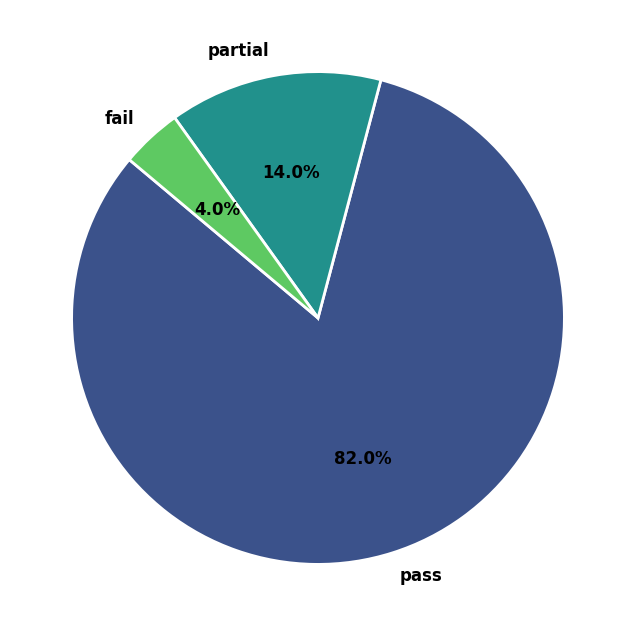

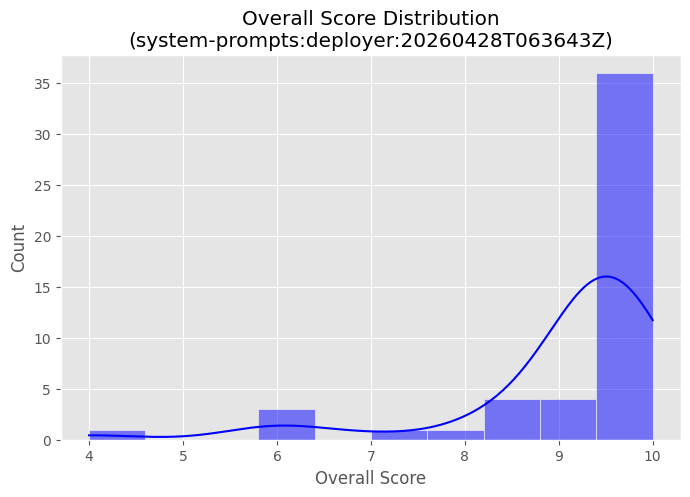

In [5]:
# Visualizations
plt.style.use('ggplot')

# Plot 1: Verdict Distribution
plt.figure(figsize=(8, 8))
colors = sns.color_palette('viridis', len(verdict_counts))

plt.pie(
    verdict_counts, 
    labels=verdict_counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 12, 'weight': 'bold'}
)

# Plot 2: Overall Score Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df_latest['overall_score'], bins=10, kde=True, color='blue')
plt.title(f'Overall Score Distribution\n({latest_prompt})')
plt.xlabel('Overall Score')
plt.savefig('score_distribution.png')

# # Plot 3: Comparison of Average Score across all prompts
# prompt_comparison = df.groupby('redis_optimization_reference')['overall_score'].mean().sort_values()
# plt.figure(figsize=(10, 6))
# prompt_comparison.plot(kind='barh', color='skyblue')
# plt.axvline(df_latest['overall_score'].mean(), color='red', linestyle='--', label='Latest Prompt Avg')
# plt.title('Average Overall Score by System Prompt Reference')
# plt.xlabel('Mean Overall Score')
# plt.ylabel('Prompt Reference')
# plt.legend()
# plt.tight_layout()
# plt.savefig('prompt_comparison.png')

# # Plot 4: Success Rate (Task Completion) by Prompt
# success_comparison = df.groupby('redis_optimization_reference')['task_completion'].mean().sort_values()
# plt.figure(figsize=(10, 6))
# success_comparison.plot(kind='barh', color='lightgreen')
# plt.title('Task Completion Rate by System Prompt Reference')
# plt.xlabel('Mean Task Completion Rate')
# plt.ylabel('Prompt Reference')
# plt.tight_layout()
# plt.savefig('success_comparison.png')

print("\nVisualizations saved: verdict_distribution.png, score_distribution.png, prompt_comparison.png, success_comparison.png")

      overall_score  plan_adherence  redis_stats_workflow_latency  \
mean       9.050000        0.976000                    138.758894   
std        1.213235        0.074396                    156.620097   
min        4.000000        0.600000                     39.699715   
max       10.000000        1.000000                    737.174857   

      redis_stats_task_total_token_cost  
mean                        8388.340000  
std                          325.524544  
min                         7792.000000  
max                         9492.000000  


/tmp/ipykernel_2436135/318958129.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_latest, x='verdict', y='redis_stats_workflow_latency', palette='Set2')


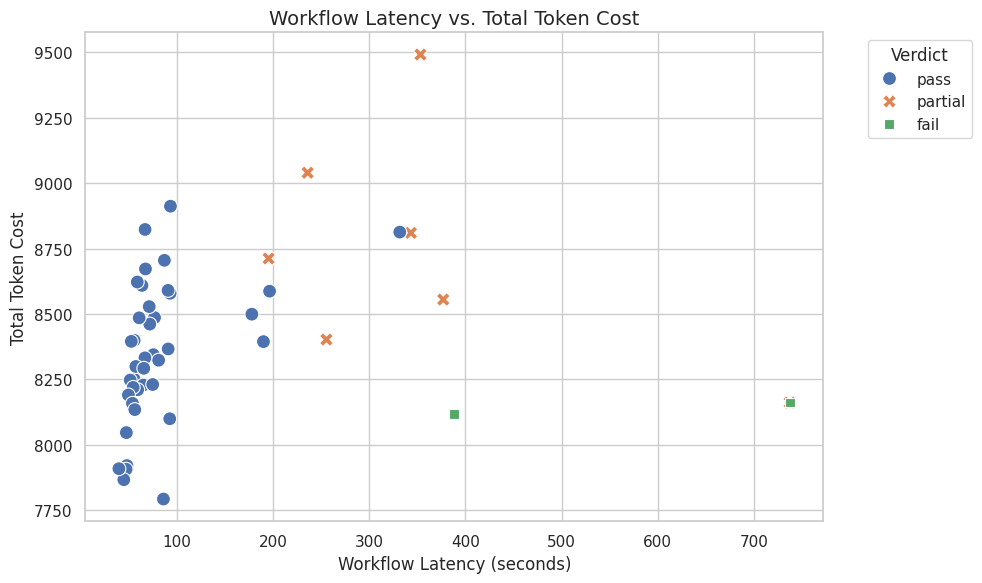

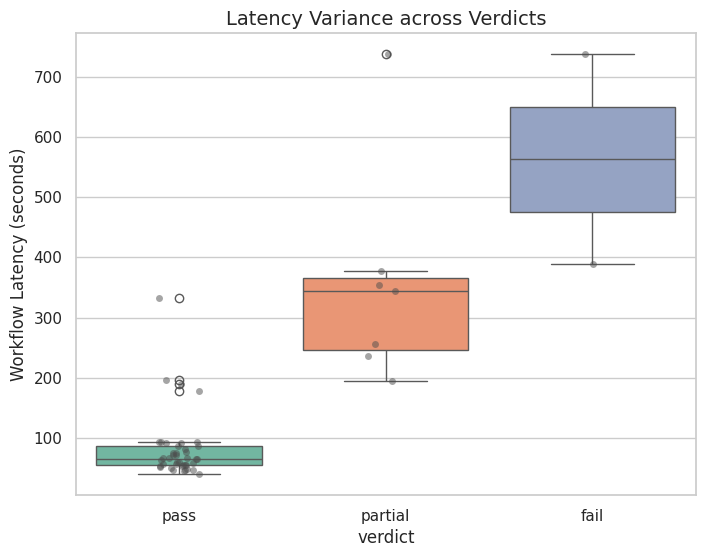

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Set aesthetic parameters for Seaborn
sns.set_theme(style="whitegrid")

# Load data

# Define the target prompt reference
df_latest = df[df['redis_optimization_reference'] == latest_prompt].copy()

# # 1. Performance Comparison: Average Score by Prompt Version
# plt.figure(figsize=(12, 6))
# avg_scores = df.groupby('redis_optimization_reference')['overall_score'].mean().sort_values(ascending=False).reset_index()
# sns.barplot(data=avg_scores, y='redis_optimization_reference', x='overall_score', palette='mako')
# plt.title('Average Overall Score across Prompt Versions', fontsize=15)
# plt.xlabel('Mean Overall Score')
# plt.ylabel('Prompt Reference')
# plt.tight_layout()
# plt.savefig('seaborn_prompt_comparison.png')

# # 2. Verdict Distribution for the Latest Prompt
# plt.figure(figsize=(8, 6))
# sns.countplot(data=df_latest, x='verdict', order=['pass', 'partial', 'fail'], palette='viridis')
# plt.title(f'Verdict Distribution\n({latest_prompt})', fontsize=14)
# plt.ylabel('Count')
# plt.xlabel('Verdict')
# plt.savefig('seaborn_verdict_dist.png')

# 3. Latency vs. Token Cost (Efficiency Analysis)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_latest, x='redis_stats_workflow_latency', y='redis_stats_task_total_token_cost', 
                hue='verdict', style='verdict', s=100, palette='deep')
plt.title('Workflow Latency vs. Total Token Cost', fontsize=14)
plt.xlabel('Workflow Latency (seconds)')
plt.ylabel('Total Token Cost')
plt.legend(title='Verdict', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('seaborn_latency_cost_scatter.png')

# # 4. Distribution of Scores for the Latest Prompt
# plt.figure(figsize=(8, 6))
# sns.histplot(df_latest['overall_score'], kde=True, color='teal', bins=10)
# plt.title(f'Distribution of Overall Scores\n({latest_prompt})', fontsize=14)
# plt.xlabel('Overall Score')
# plt.savefig('seaborn_score_hist.png')

# 5. Boxplot of Latency by Verdict
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_latest, x='verdict', y='redis_stats_workflow_latency', palette='Set2')
sns.stripplot(data=df_latest, x='verdict', y='redis_stats_workflow_latency', color=".3", alpha=0.5)
plt.title('Latency Variance across Verdicts', fontsize=14)
plt.ylabel('Workflow Latency (seconds)')
plt.savefig('seaborn_latency_boxplot.png')

# Output some summary data for the final text response
latest_stats = df_latest.describe().loc[['mean', 'std', 'min', 'max']]
print(latest_stats[['overall_score', 'plan_adherence', 'redis_stats_workflow_latency', 'redis_stats_task_total_token_cost']])

/tmp/ipykernel_2436135/3242039449.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2436135/3242039449.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


                                          avg_score  pass_rate  sample_size
redis_optimization_reference                                               
system-prompts:deployer:base               8.100000   0.640000           25
system-prompts:deployer:20260416T004153Z   8.520000   0.760000           25
system-prompts:deployer:20260418T045038Z   8.280000   0.680000           25
system-prompts:deployer:20260419T101428Z   8.900000   0.760000           25
system-prompts:deployer:20260420T161010Z   8.666667   0.777778           45
system-prompts:deployer:20260421T122549Z   8.260000   0.720000           25
system-prompts:deployer:20260422T005928Z   8.753333   0.800000           75
system-prompts:deployer:20260428T063643Z   9.050000   0.820000           50


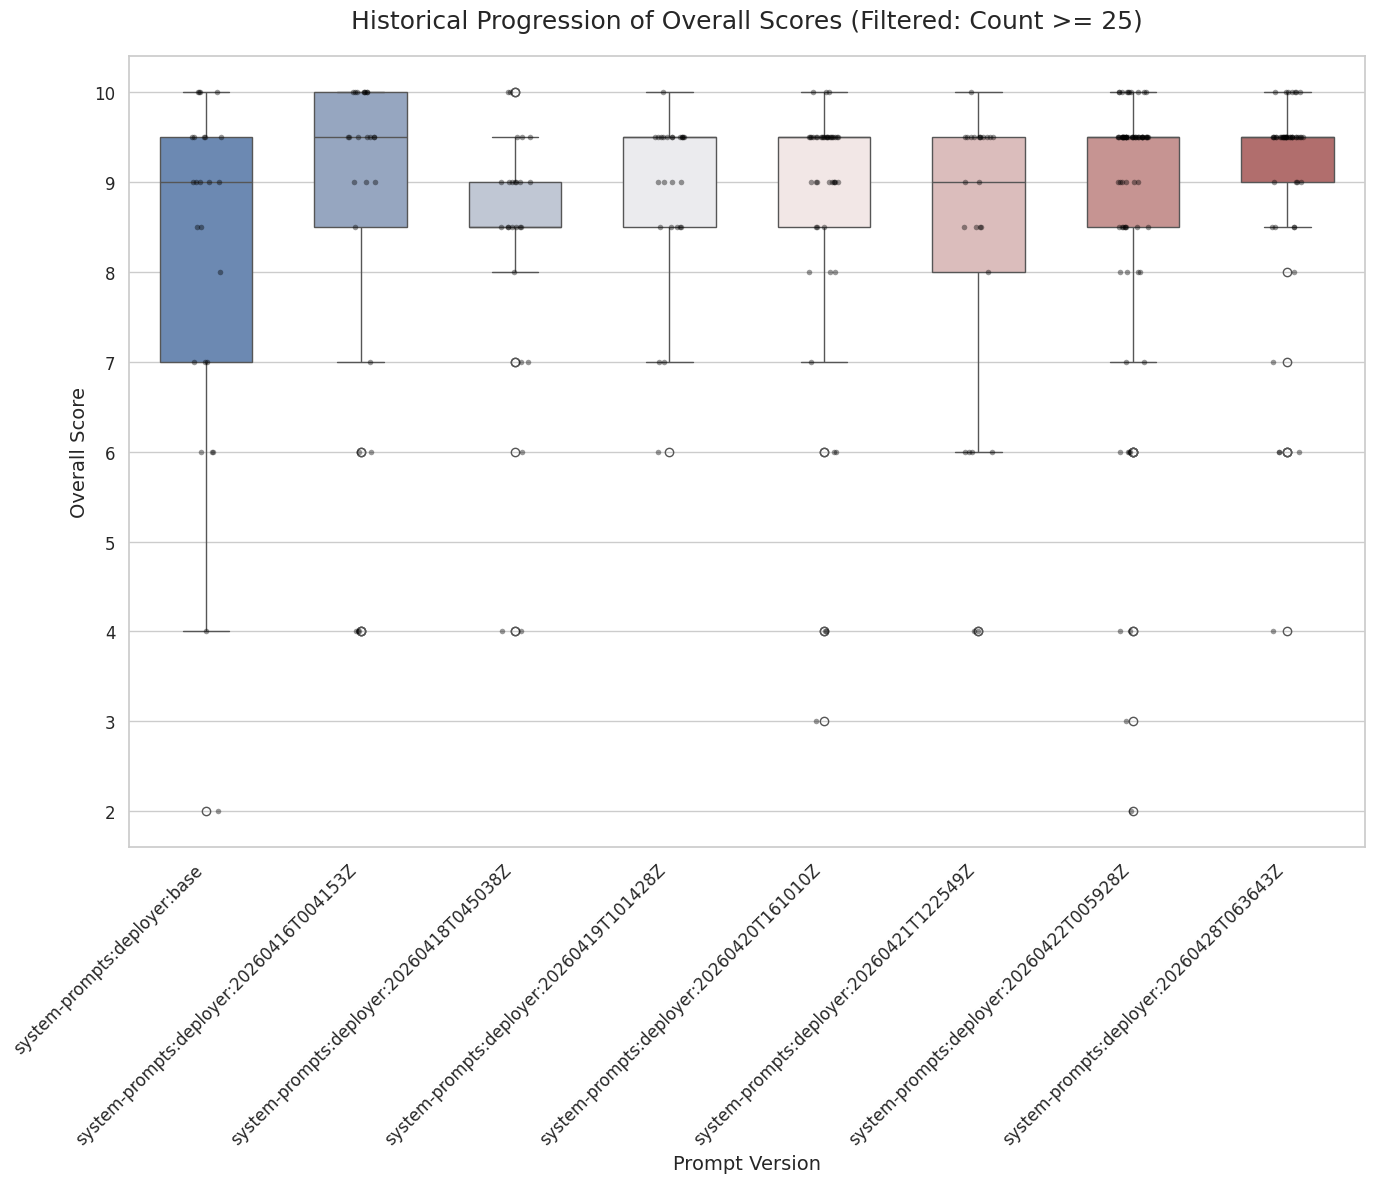

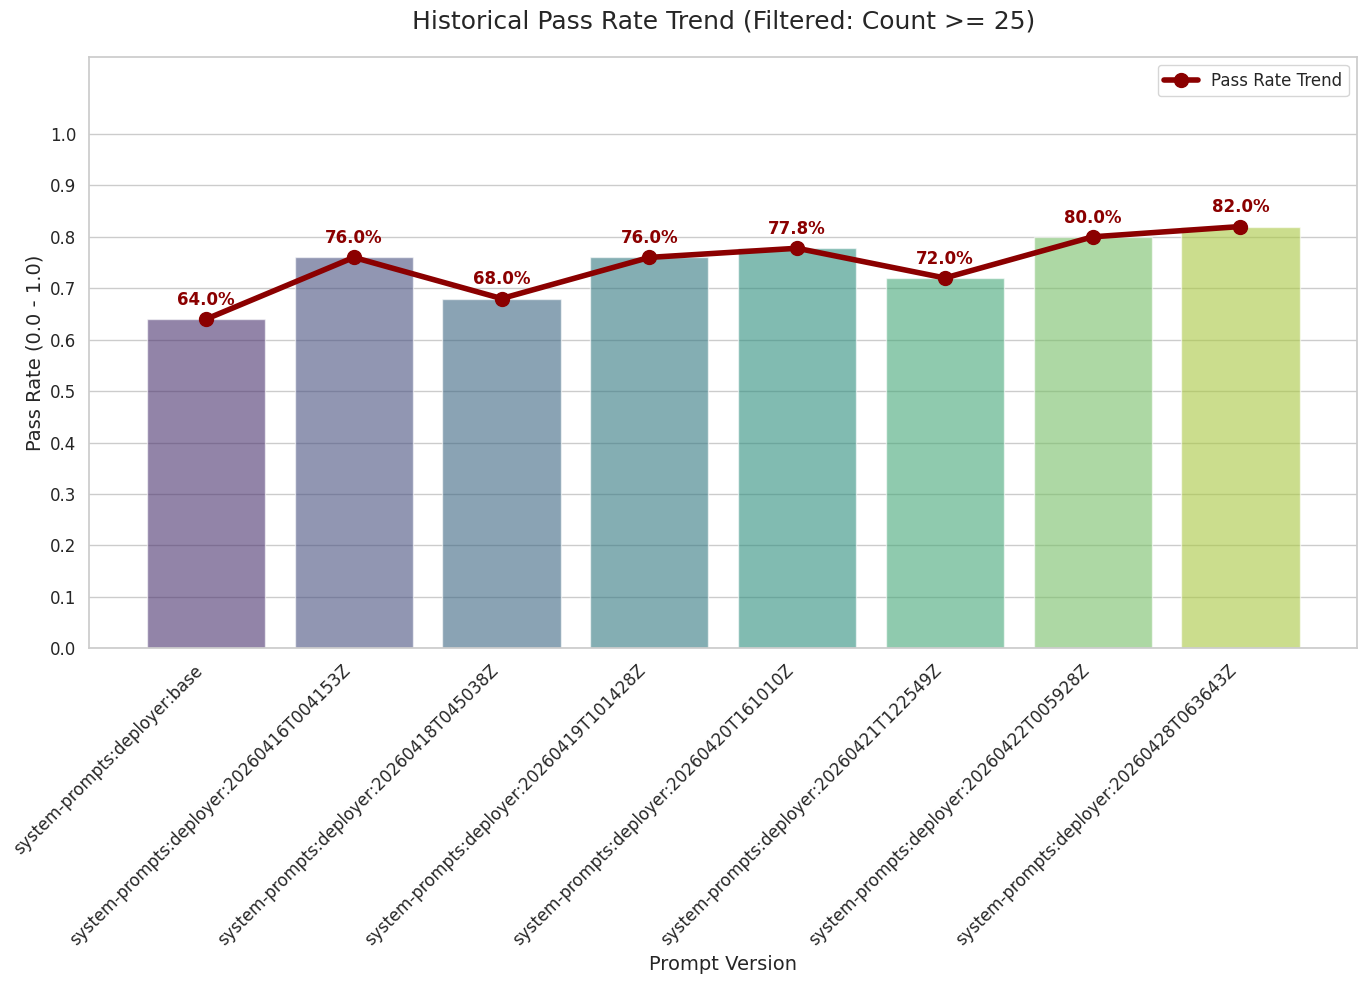

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Set theme
sns.set_theme(style="whitegrid")

# Load the data

# 1. Filter out batches with count < 25
counts = df['redis_optimization_reference'].value_counts()
valid_prompts = counts[counts >= 25].index
df_filtered = df[df['redis_optimization_reference'].isin(valid_prompts)].copy()

# 2. Sort chronologically
def get_sort_key(prompt):
    if 'base' in prompt:
        return '00000000T000000Z'
    return prompt.split(':')[-1]

df_filtered['sort_key'] = df_filtered['redis_optimization_reference'].apply(get_sort_key)
sorted_prompts = df_filtered.sort_values('sort_key')['redis_optimization_reference'].unique()

# Summary table for text
summary = df_filtered.groupby('redis_optimization_reference').agg(
    avg_score=('overall_score', 'mean'),
    pass_rate=('verdict', lambda x: (x == 'pass').sum() / len(x)),
    sample_size=('overall_score', 'count')
).reindex(sorted_prompts)

# 3. Enhanced Boxplot (Taller)
plt.figure(figsize=(14, 12)) # Increased height significantly
sns.boxplot(
    data=df_filtered, 
    x='redis_optimization_reference', 
    y='overall_score', 
    order=sorted_prompts,
    palette='vlag',
    width=0.6
)
sns.stripplot(
    data=df_filtered, 
    x='redis_optimization_reference', 
    y='overall_score', 
    order=sorted_prompts,
    color='black', 
    alpha=0.4, 
    size=4
)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.title('Historical Progression of Overall Scores (Filtered: Count >= 25)', fontsize=18, pad=20)
plt.xlabel('Prompt Version', fontsize=14)
plt.ylabel('Overall Score', fontsize=14)
plt.tight_layout()
plt.savefig('historical_scores_boxplot_tall.png')

# 4. Enhanced Pass Rate Progression (Taller)
pass_rates = summary.reset_index()
pass_rates.columns = ['prompt', 'avg_score', 'pass_rate', 'sample_size']

plt.figure(figsize=(14, 10)) # Increased height
# Bar plot
sns.barplot(
    data=pass_rates, 
    x='prompt', 
    y='pass_rate', 
    palette='viridis',
    alpha=0.6,
    order=sorted_prompts
)
# Line plot with bold markers
plt.plot(
    np.arange(len(pass_rates)), 
    pass_rates['pass_rate'], 
    marker='o', 
    color='darkred', 
    linewidth=4, 
    markersize=10, 
    label='Pass Rate Trend'
)

# Annotate the trend line with percentages
for i, rate in enumerate(pass_rates['pass_rate']):
    plt.text(i, rate + 0.02, f'{rate:.1%}', ha='center', va='bottom', fontsize=12, fontweight='bold', color='darkred')

plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(np.arange(0, 1.1, 0.1), fontsize=12)
plt.title('Historical Pass Rate Trend (Filtered: Count >= 25)', fontsize=18, pad=20)
plt.xlabel('Prompt Version', fontsize=14)
plt.ylabel('Pass Rate (0.0 - 1.0)', fontsize=14)
plt.ylim(0, 1.15) # Leave room for labels
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('historical_pass_rate_tall.png')

print(summary)

Verification of target parent:
                                   redis_key  \
19  system-prompts:deployer:20260428T063643Z   

                                  parent_key  
19  system-prompts:deployer:20260421T122549Z  

Final Data Mapping:
                                  redis_key  \
0  system-prompts:deployer:20260416T004153Z   
1  system-prompts:deployer:20260418T045038Z   
2  system-prompts:deployer:20260419T101428Z   
3  system-prompts:deployer:20260420T161010Z   
4  system-prompts:deployer:20260421T122549Z   
5  system-prompts:deployer:20260422T005928Z   
6  system-prompts:deployer:20260428T063643Z   

                                 parent_key  avg_score  
0                                       NaN   8.520000  
1  system-prompts:deployer:20260416T004153Z   8.280000  
2  system-prompts:deployer:20260418T045038Z   8.900000  
3  system-prompts:deployer:20260419T101428Z   8.666667  
4  system-prompts:deployer:20260420T142234Z   8.260000  
5  system-prompts:deployer:20260421T12

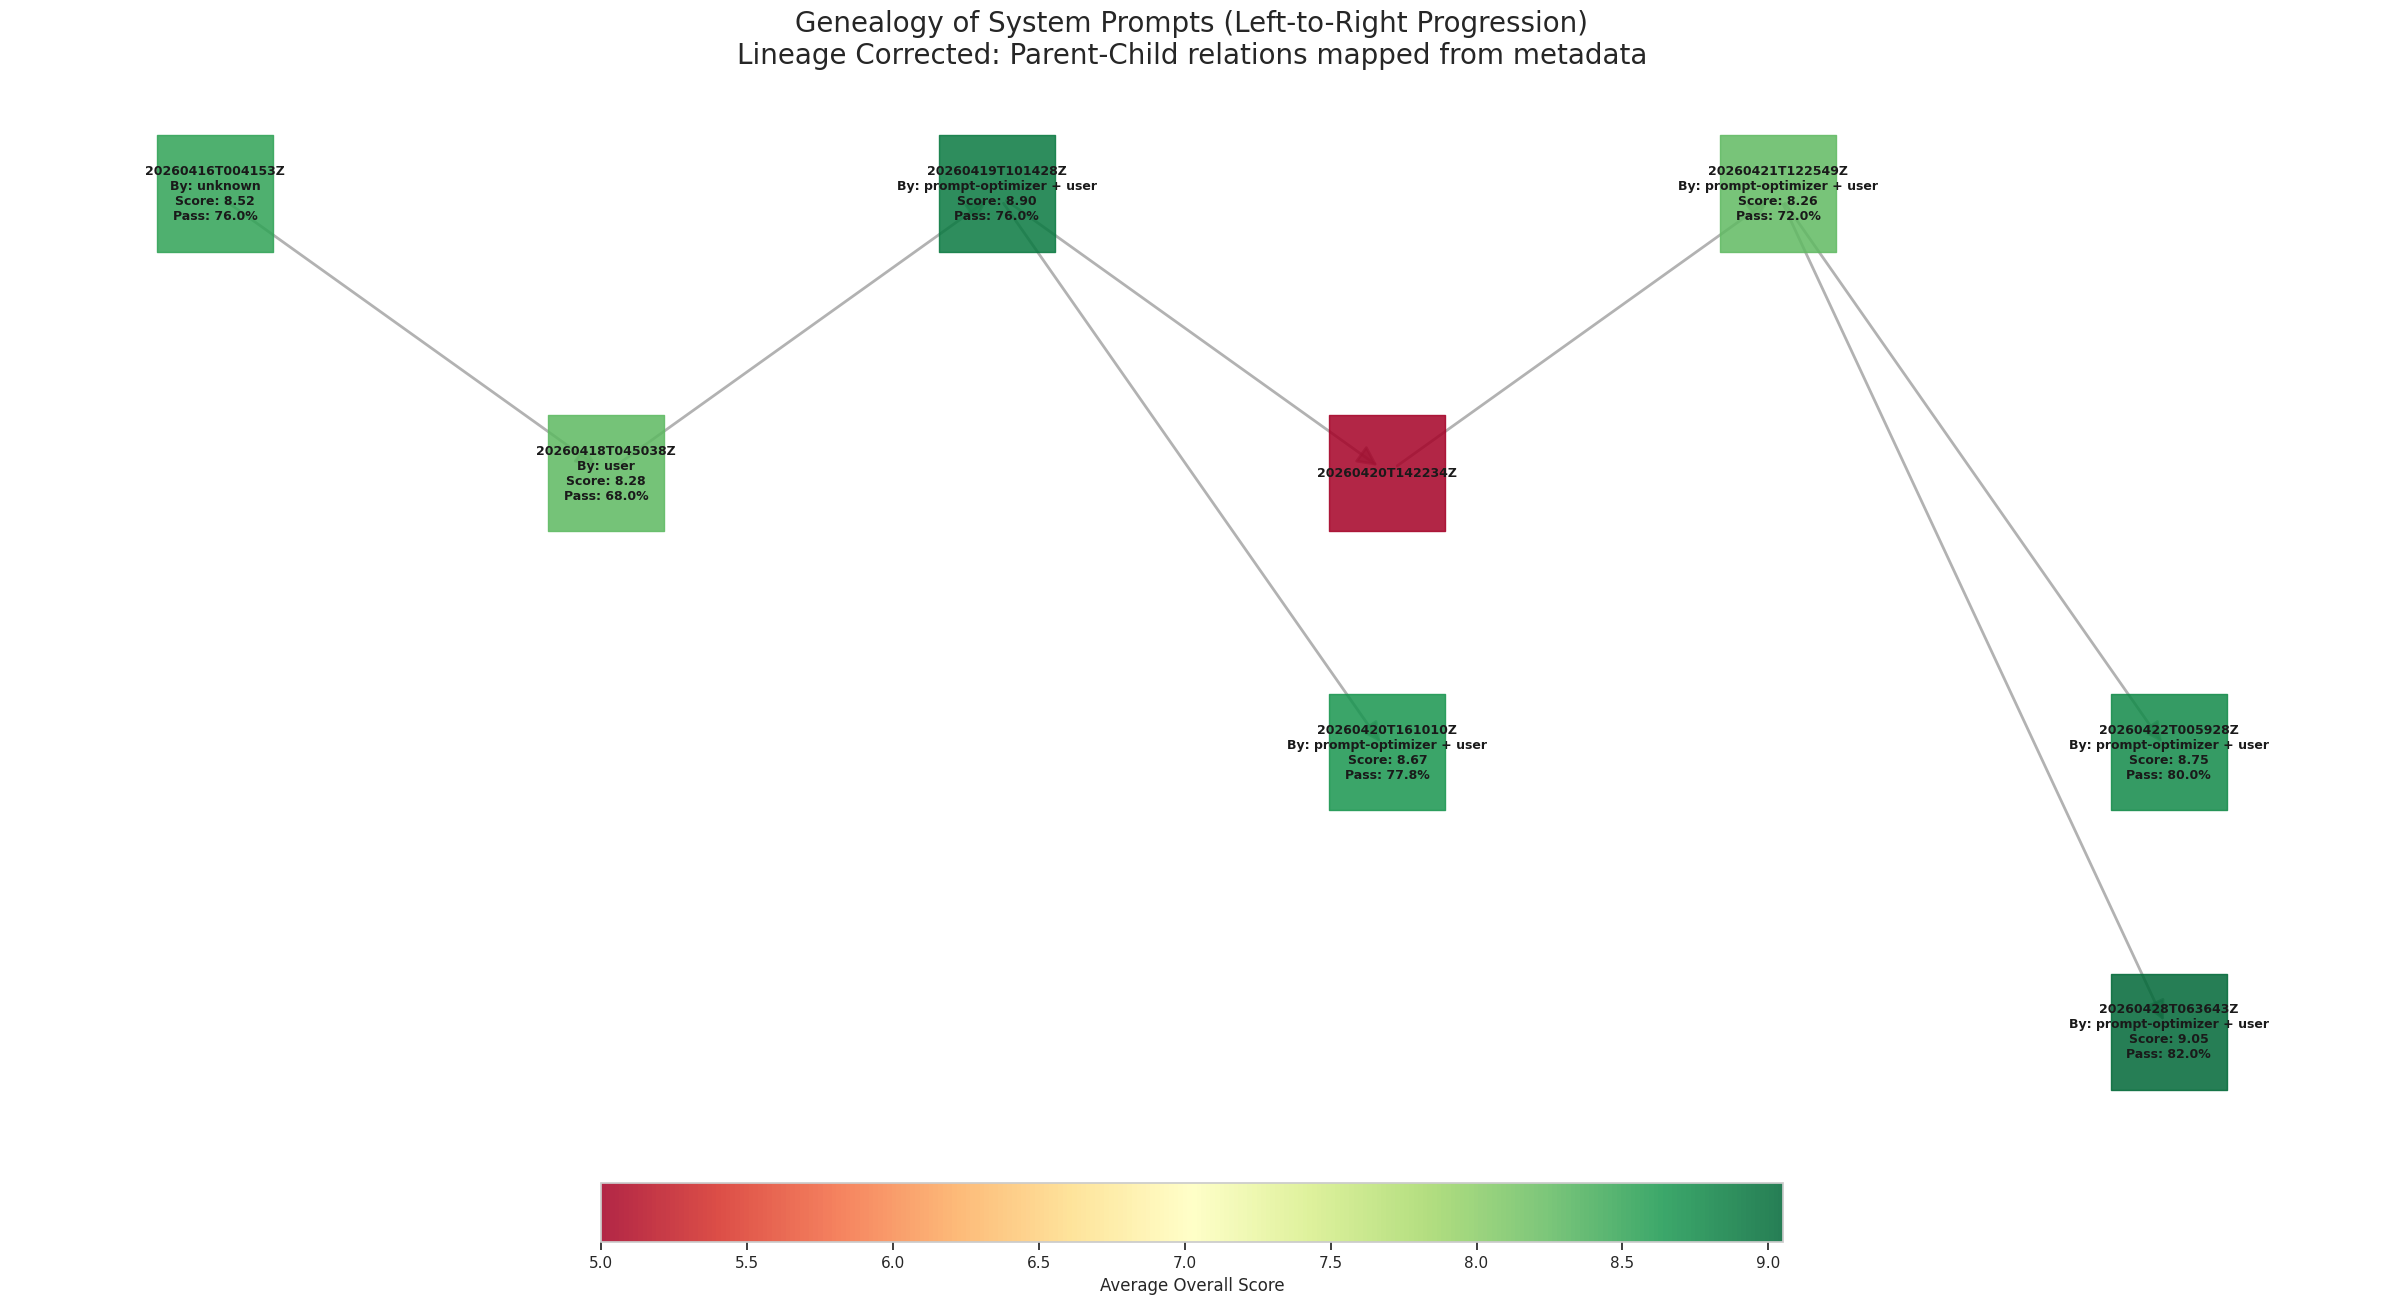

In [26]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Load the data files
df_raw = df 
df_meta = pd.read_csv('../output/system_prompts_deployer.csv')

# 1. Clean metadata: Merge the two potential parent columns
# The colon at the end of 'remarks_optimized_from:' suggests a parsing artifact or intentional split
df_meta['parent_key'] = df_meta['remarks_optimized_from'].fillna(df_meta['remarks_optimized_from:'])

# Verify the specific row the user mentioned
target_row = df_meta[df_meta['redis_key'] == latest_prompt]
print("Verification of target parent:")
print(target_row[['redis_key', 'parent_key']])

# 2. Filter performance data (N >= 25)
counts = df_raw['redis_optimization_reference'].value_counts()
valid_prompts = counts[counts >= 25].index
df_raw_filtered = df_raw[df_raw['redis_optimization_reference'].isin(valid_prompts)].copy()

# 3. Calculate metrics
perf_stats = df_raw_filtered.groupby('redis_optimization_reference').agg(
    pass_rate=('verdict', lambda x: (x == 'pass').mean()),
    avg_score=('overall_score', 'mean')
).reset_index()

# 4. Merge
df_tree_data = pd.merge(
    df_meta[['redis_key', 'remarks_created_by', 'parent_key']],
    perf_stats,
    left_on='redis_key',
    right_on='redis_optimization_reference',
    how='inner'
)

# 5. Build Graph
G = nx.DiGraph()
# Add all edges from meta to preserve lineage, even for nodes without metrics
for _, row in df_meta.iterrows():
    child = row['redis_key']
    parent = row['parent_key']
    if pd.notna(parent) and parent.strip() != "":
        G.add_edge(parent, child)

# 6. Position logic for Left-to-Right
def get_lr_pos(G):
    # Calculate level (X)
    levels = {}
    roots = [n for n, d in G.in_degree() if d == 0]
    for r in roots:
        for node, depth in nx.shortest_path_length(G, source=r).items():
            levels[node] = max(levels.get(node, 0), depth)
    
    # Calculate spread (Y)
    pos = {}
    level_counts = {}
    for node, level in sorted(levels.items(), key=lambda x: x[1]):
        level_counts[level] = level_counts.get(level, 0) + 1
        pos[node] = (level, -level_counts[level])
    return pos

pos = get_lr_pos(G)

# 7. Visualization
plt.figure(figsize=(24, 14))

# Only draw nodes that are in our performance dataset or are part of the direct lineage path
# For clarity, let's draw the nodes that have performance data
nodes_to_draw = [n for n in G.nodes() if n in df_tree_data['redis_key'].values]
# Add parents/ancestors of these nodes to ensure connections work
lineage_nodes = set(nodes_to_draw)
for n in nodes_to_draw:
    # Get ancestors
    if n in G:
        lineage_nodes.update(nx.ancestors(G, n))

# Filter G to just these nodes for a cleaner diagram
G_sub = G.subgraph(lineage_nodes)

# Prepare lists for drawing nodes with data vs placeholder nodes
node_colors = []
node_labels = {}
final_nodes_to_draw = list(G_sub.nodes())

for node in final_nodes_to_draw:
    if node in df_tree_data['redis_key'].values:
        row = df_tree_data[df_tree_data['redis_key'] == node].iloc[0]
        node_colors.append(row['avg_score'])
        name = node.split(':')[-1]
        creator = row['remarks_created_by'] if pd.notna(row['remarks_created_by']) else "unknown"
        node_labels[node] = f"{name}\nBy: {creator}\nScore: {row['avg_score']:.2f}\nPass: {row['pass_rate']:.1%}"
    else:
        node_colors.append(5.0) # Neutral score for placeholders
        node_labels[node] = node.split(':')[-1]

# Draw
nodes_plot = nx.draw_networkx_nodes(
    G_sub, pos, node_size=7000, 
    node_color=node_colors, cmap=plt.cm.RdYlGn, 
    alpha=0.85, node_shape='s'
)

nx.draw_networkx_edges(G_sub, pos, arrowstyle='-|>', arrowsize=30, edge_color='gray', width=2, alpha=0.6)
nx.draw_networkx_labels(G_sub, pos, labels=node_labels, font_size=9, font_weight='bold')

plt.title('Genealogy of System Prompts (Left-to-Right Progression)\nLineage Corrected: Parent-Child relations mapped from metadata', fontsize=20, pad=30)
plt.colorbar(nodes_plot, label='Average Overall Score', orientation='horizontal', shrink=0.5, pad=0.05)
plt.axis('off')
plt.tight_layout()
plt.savefig('corrected_genealogy_tree_lr.png')

# Output data verification
df_tree_data.to_csv('verified_genealogy_data.csv', index=False)
print("\nFinal Data Mapping:")
print(df_tree_data[['redis_key', 'parent_key', 'avg_score']])

Mapping verification:
Node: 20260416T004153Z | Generation: 0 | Score: 8.52
Node: 20260418T045038Z | Generation: 1 | Score: 8.28
Node: 20260419T101428Z | Generation: 2 | Score: 8.90
Node: 20260420T161010Z | Generation: 3 | Score: 8.67
Node: 20260421T122549Z | Generation: 4 | Score: 8.26
Node: 20260422T005928Z | Generation: 5 | Score: 8.75
Node: 20260428T063643Z | Generation: 5 | Score: 9.05


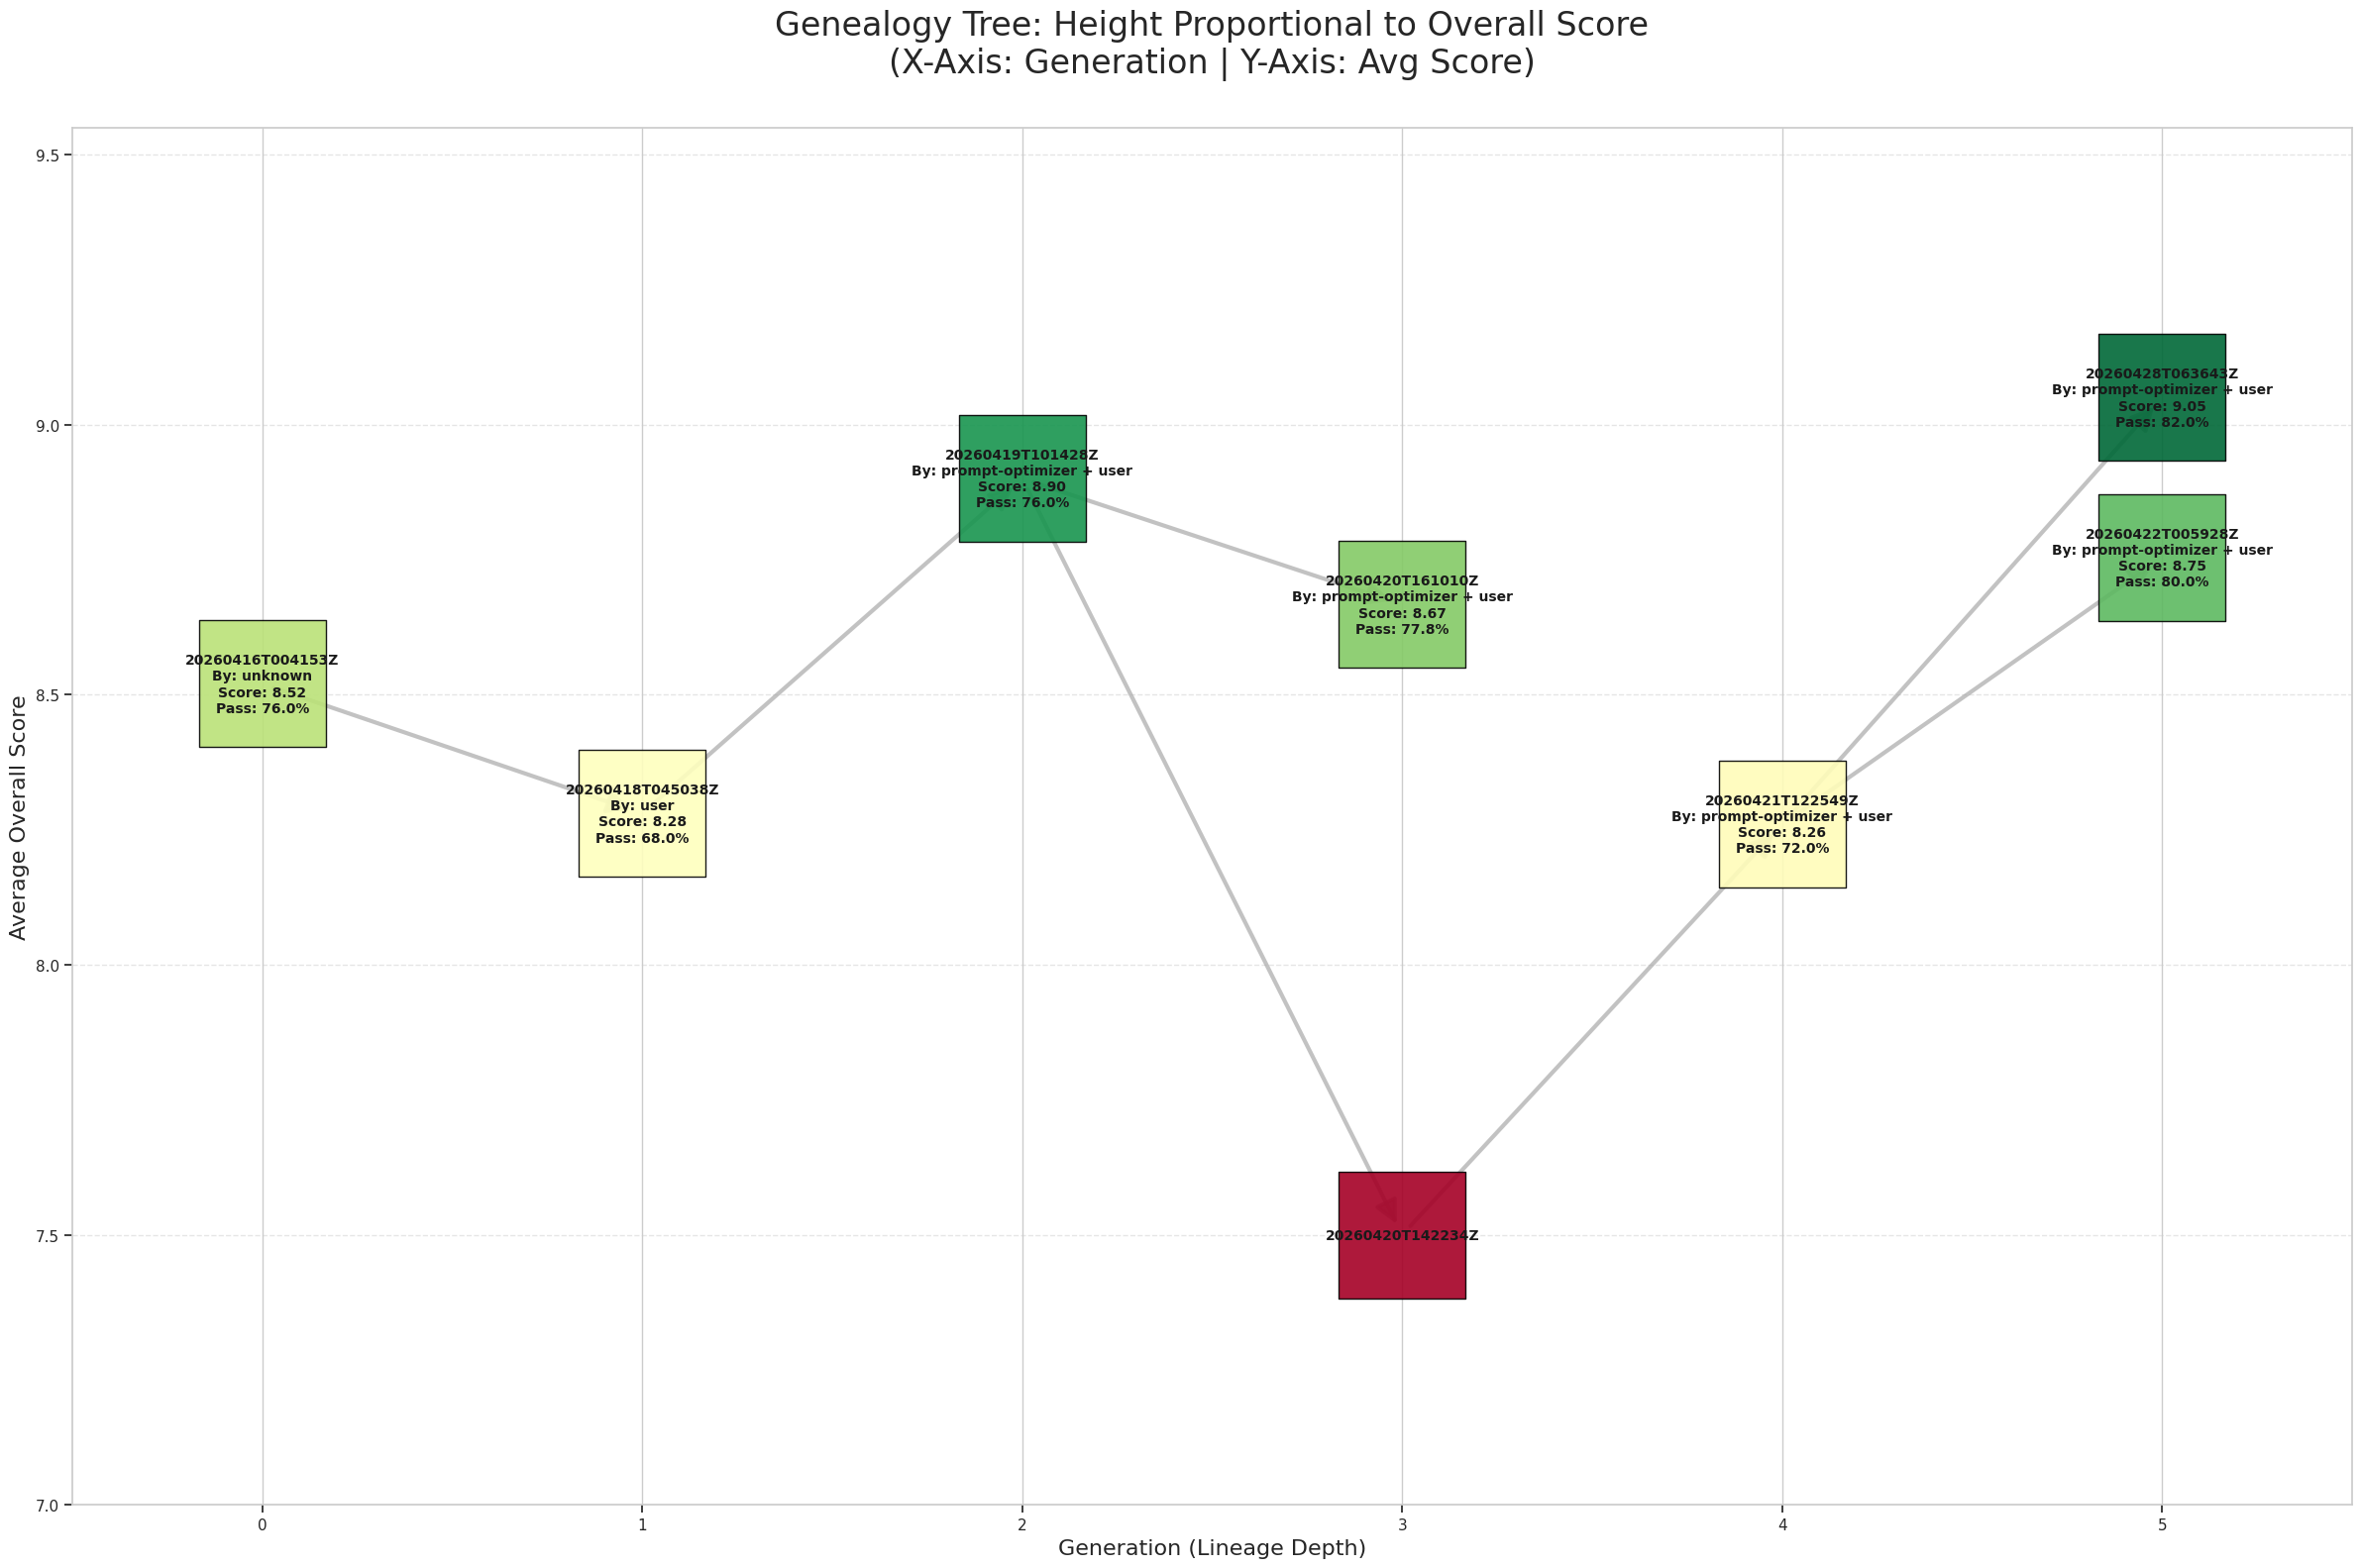

In [27]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Load files
df_raw = df 
df_meta = pd.read_csv('../output/system_prompts_deployer.csv')

# Pre-processing metadata for Genealogy
def get_parent(row):
    p1 = str(row['remarks_optimized_from']).strip() if pd.notna(row['remarks_optimized_from']) else ""
    p2 = str(row['remarks_optimized_from:']).strip() if pd.notna(row['remarks_optimized_from:']) else ""
    return p2 if p2 != "" else p1

df_meta['parent_key'] = df_meta.apply(get_parent, axis=1)

# Filter performance data (N >= 25)
counts = df_raw['redis_optimization_reference'].value_counts()
valid_prompts = counts[counts >= 25].index
df_raw_filtered = df_raw[df_raw['redis_optimization_reference'].isin(valid_prompts)].copy()

# Metrics
perf_stats = df_raw_filtered.groupby('redis_optimization_reference').agg(
    pass_rate=('verdict', lambda x: (x == 'pass').mean()),
    avg_score=('overall_score', 'mean')
).reset_index()

# Merge
df_merged = pd.merge(
    df_meta[['redis_key', 'remarks_created_by', 'parent_key']],
    perf_stats,
    left_on='redis_key',
    right_on='redis_optimization_reference',
    how='inner'
)

# Build Genealogy Graph
G = nx.DiGraph()
# Add edges from meta
for _, row in df_meta.iterrows():
    child = row['redis_key']
    parent = row['parent_key']
    if pd.notna(parent) and parent != "":
        G.add_edge(parent, child)

# Filter Graph to only nodes with data
nodes_with_data = set(df_merged['redis_key'])
# To make a continuous tree, include ancestors of nodes with data
lineage_nodes = set(nodes_with_data)
for n in nodes_with_data:
    if n in G:
        lineage_nodes.update(nx.ancestors(G, n))
G_sub = G.subgraph(lineage_nodes)

# Position Logic: 
# X = Depth (Generation)
# Y = Average Score
def get_score_layered_pos(G, score_map):
    # Determine depth from roots
    roots = [n for n, d in G.in_degree() if d == 0]
    depths = {}
    for r in roots:
        d = nx.shortest_path_length(G, source=r)
        for node, val in d.items():
            depths[node] = max(depths.get(node, 0), val)
    
    pos = {}
    for node in G.nodes():
        x = depths.get(node, 0)
        # Use score for Y if available, else use a placeholder or parent's score
        y = score_map.get(node, 7.5) # Default/Base score if no data
        pos[node] = (x, y)
    return pos

# Create score map for positioning
score_map = dict(zip(df_merged['redis_key'], df_merged['avg_score']))
# For nodes without direct scores in df_merged, try to infer or use base
# Let's just use the df_merged keys for the map.

pos = get_score_layered_pos(G_sub, score_map)

# Visualization
plt.figure(figsize=(24, 16))

node_colors = []
node_labels = {}
all_nodes = list(G_sub.nodes())

for node in all_nodes:
    if node in nodes_with_data:
        row = df_merged[df_merged['redis_key'] == node].iloc[0]
        node_colors.append(row['avg_score'])
        name = node.split(':')[-1]
        creator = row['remarks_created_by'] if pd.notna(row['remarks_created_by']) else "unknown"
        node_labels[node] = f"{name}\nBy: {creator}\nScore: {row['avg_score']:.2f}\nPass: {row['pass_rate']:.1%}"
    else:
        node_colors.append(7.5) # Neutral for placeholders
        node_labels[node] = node.split(':')[-1]

# Draw nodes
nodes_plot = nx.draw_networkx_nodes(
    G_sub, pos, node_size=8500, 
    node_color=node_colors, cmap=plt.cm.RdYlGn, 
    alpha=0.9, node_shape='s', edgecolors='black'
)

# Draw connections
nx.draw_networkx_edges(G_sub, pos, arrowstyle='-|>', arrowsize=35, edge_color='darkgrey', alpha=0.7, width=3)

# Draw labels
nx.draw_networkx_labels(G_sub, pos, labels=node_labels, font_size=10, font_weight='bold')

plt.title('Genealogy Tree: Height Proportional to Overall Score\n(X-Axis: Generation | Y-Axis: Avg Score)', fontsize=24, pad=40)
plt.xlabel('Generation (Lineage Depth)', fontsize=16)
plt.ylabel('Average Overall Score', fontsize=16)

# Add y-axis grid to emphasize score proportionality
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tick_params(left=True, bottom=True, labelleft=True, labelbottom=True)

# Set axes limits for better viewing
scores = [pos[n][1] for n in all_nodes]
plt.ylim(min(scores) - 0.5, max(scores) + 0.5)
plt.xlim(-0.5, max([pos[n][0] for n in all_nodes]) + 0.5)

plt.tight_layout()
plt.savefig('genealogy_tree_score_proportional.png')

print("Mapping verification:")
for n in all_nodes:
    if n in nodes_with_data:
        print(f"Node: {n.split(':')[-1]} | Generation: {pos[n][0]} | Score: {pos[n][1]:.2f}")

Mapping verification (Pass Rate):
Node: 20260416T004153Z | Gen: 0 | Pass Rate: 76.0%
Node: 20260418T045038Z | Gen: 1 | Pass Rate: 68.0%
Node: 20260419T101428Z | Gen: 2 | Pass Rate: 76.0%
Node: 20260420T161010Z | Gen: 3 | Pass Rate: 77.8%
Node: 20260421T122549Z | Gen: 4 | Pass Rate: 72.0%
Node: 20260422T005928Z | Gen: 5 | Pass Rate: 80.0%
Node: 20260428T063643Z | Gen: 5 | Pass Rate: 82.0%


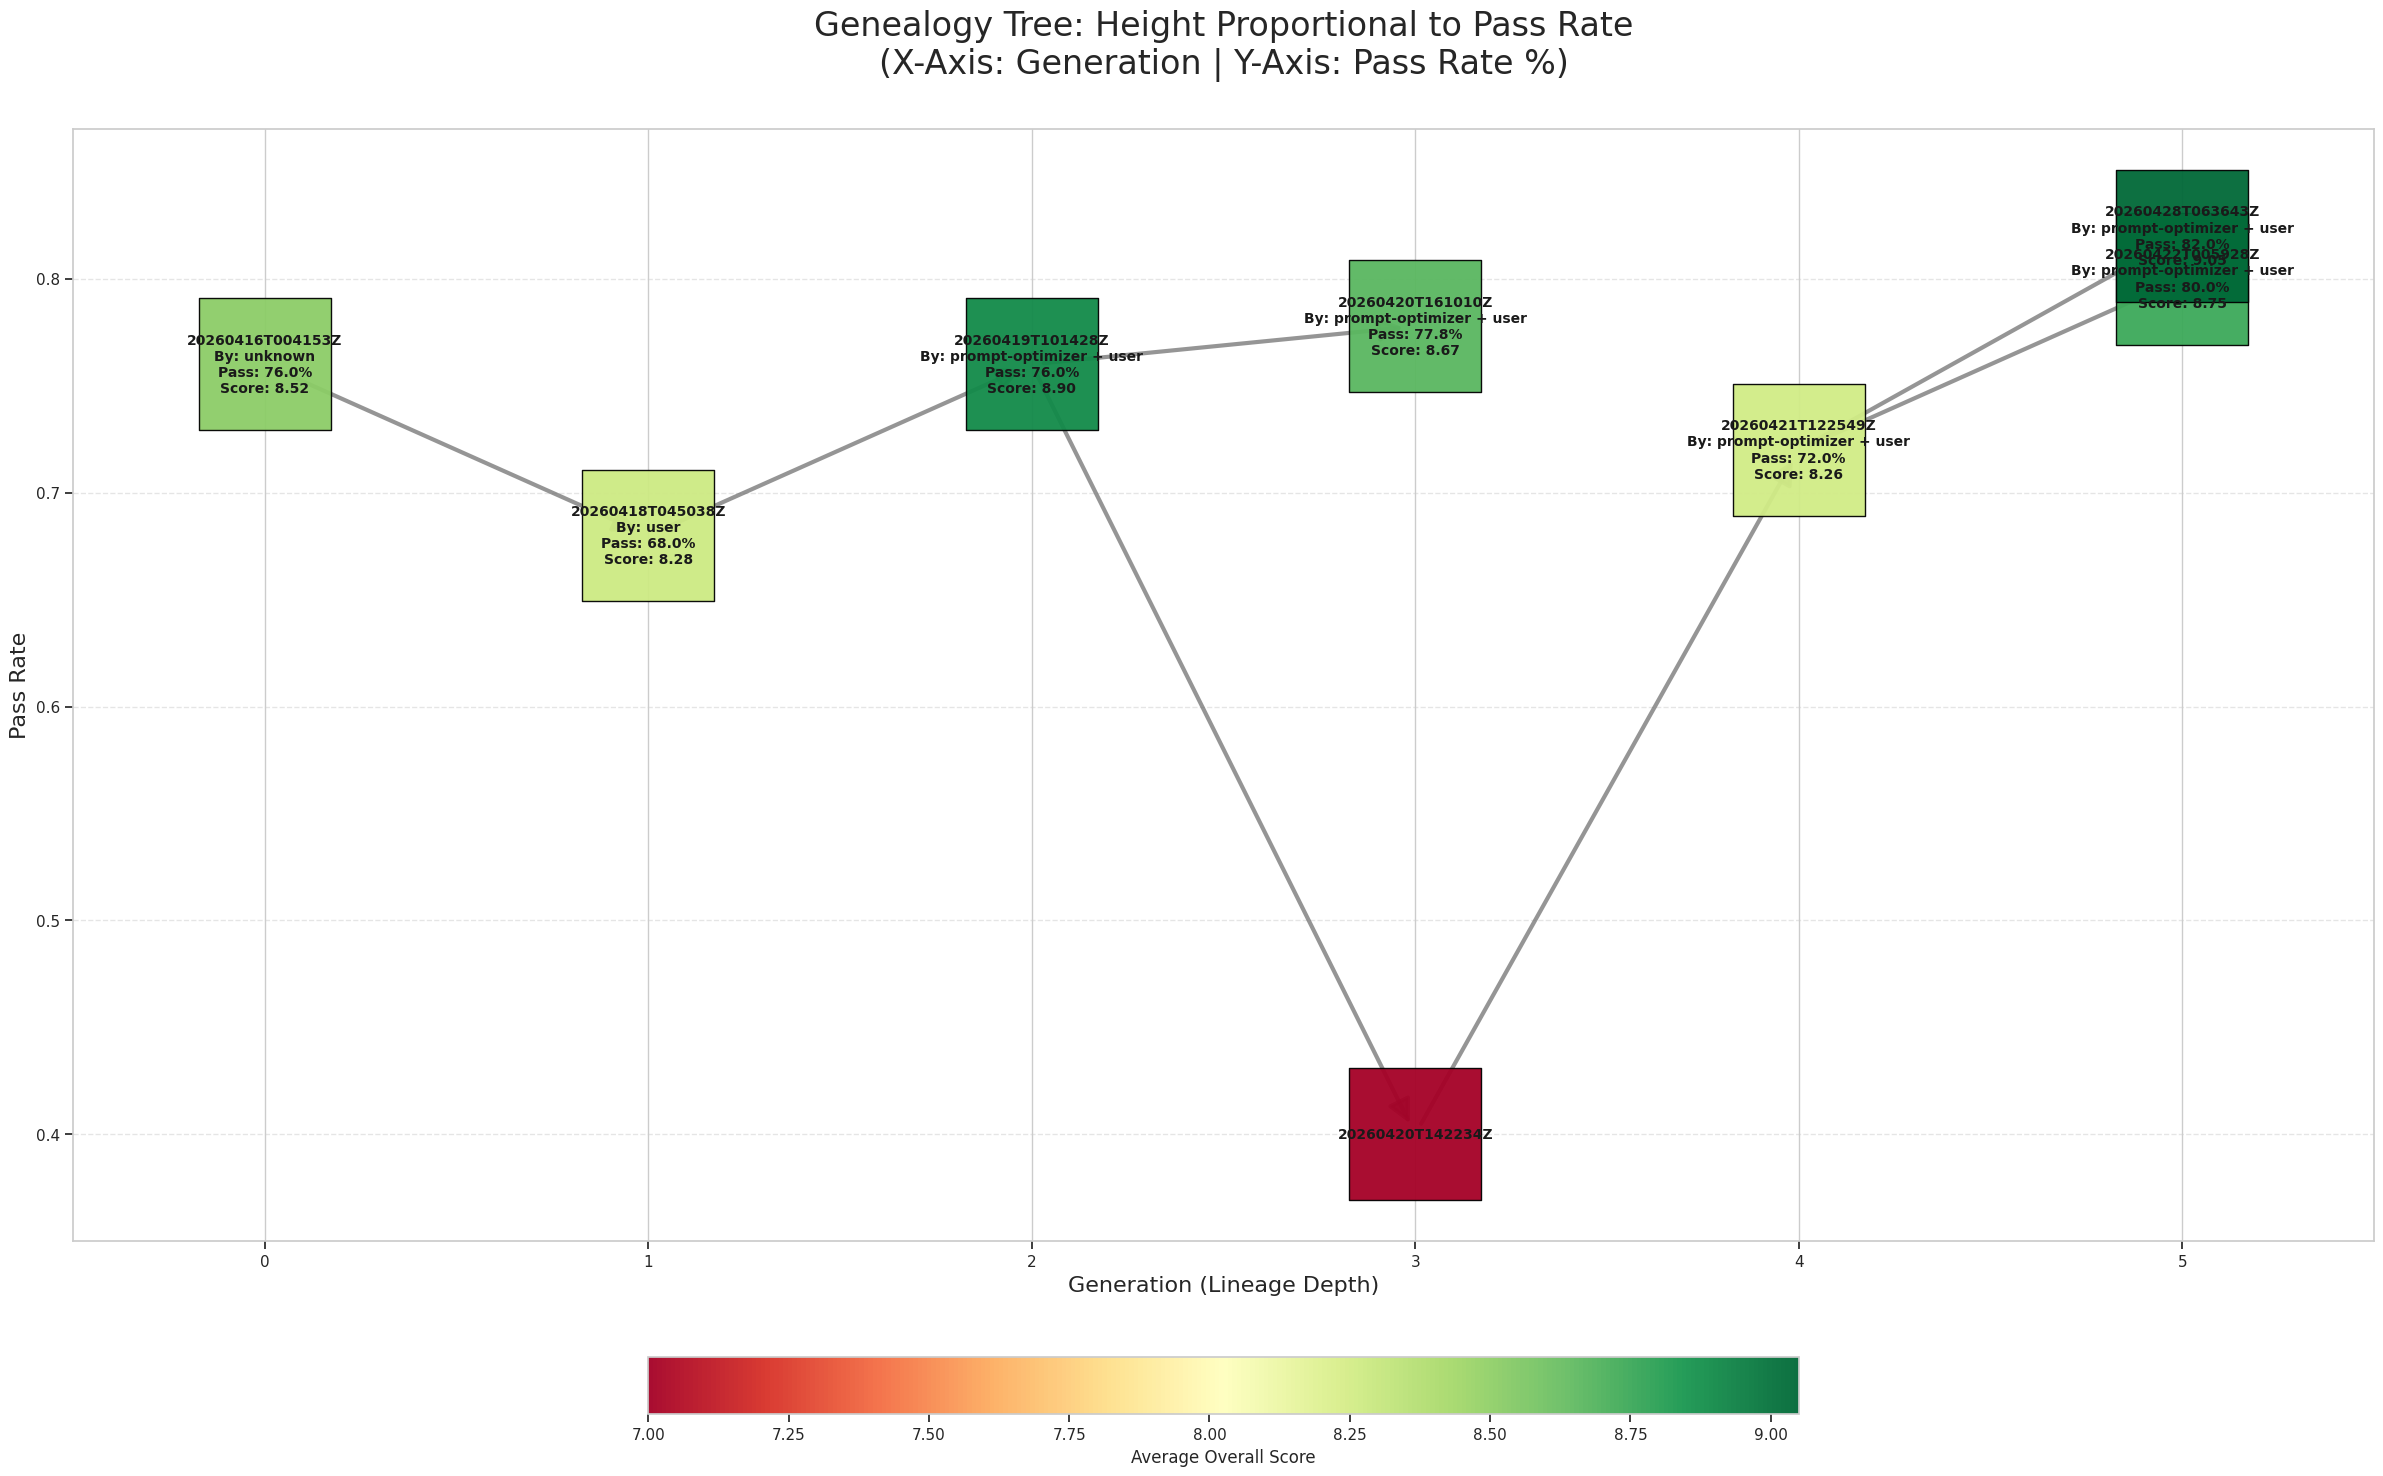

In [31]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Load files
#df_raw = pd.read_csv('deployer_raw_q3_trtllm.csv')
#df_meta = pd.read_csv('system_prompts_deployer.csv')

# Pre-processing metadata for Genealogy
# Merge the two parent columns as identified previously
def get_parent(row):
    p1 = str(row['remarks_optimized_from']).strip() if pd.notna(row['remarks_optimized_from']) else ""
    p2 = str(row['remarks_optimized_from:']).strip() if pd.notna(row['remarks_optimized_from:']) else ""
    return p2 if p2 != "" else p1

df_meta['parent_key'] = df_meta.apply(get_parent, axis=1)

# Filter performance data (N >= 25)
counts = df_raw['redis_optimization_reference'].value_counts()
valid_prompts = counts[counts >= 25].index
df_raw_filtered = df_raw[df_raw['redis_optimization_reference'].isin(valid_prompts)].copy()

# Calculate Performance Metrics
perf_stats = df_raw_filtered.groupby('redis_optimization_reference').agg(
    pass_rate=('verdict', lambda x: (x == 'pass').mean()),
    avg_score=('overall_score', 'mean')
).reset_index()

# Merge metrics into metadata
df_merged = pd.merge(
    df_meta[['redis_key', 'remarks_created_by', 'parent_key']],
    perf_stats,
    left_on='redis_key',
    right_on='redis_optimization_reference',
    how='inner'
)

# Build Genealogy Graph
G = nx.DiGraph()
for _, row in df_meta.iterrows():
    child = row['redis_key']
    parent = row['parent_key']
    if pd.notna(parent) and parent != "":
        G.add_edge(parent, child)

# Identify nodes with data and their ancestors for a complete tree
nodes_with_data = set(df_merged['redis_key'])
lineage_nodes = set(nodes_with_data)
for n in nodes_with_data:
    if n in G:
        lineage_nodes.update(nx.ancestors(G, n))
G_sub = G.subgraph(lineage_nodes)

# Position Logic:
# X = Depth (Generation)
# Y = Pass Rate
def get_pass_rate_layered_pos(G, pass_rate_map):
    # Determine depth from roots
    roots = [n for n, d in G.in_degree() if d == 0]
    depths = {}
    for r in roots:
        try:
            d_map = nx.shortest_path_length(G, source=r)
            for node, val in d_map.items():
                depths[node] = max(depths.get(node, 0), val)
        except:
            continue
    
    pos = {}
    for node in G.nodes():
        x = depths.get(node, 0)
        # Use pass_rate for Y if available
        # If node is a placeholder (ancestor with no data), we default to a baseline or parent value
        y = pass_rate_map.get(node, 0.4) # Default placeholder pass rate
        pos[node] = (x, y)
    return pos

# Create map for Y positioning
pass_rate_map = dict(zip(df_merged['redis_key'], df_merged['pass_rate']))
pos = get_pass_rate_layered_pos(G_sub, pass_rate_map)

# Visualization
plt.figure(figsize=(24, 16))

node_colors = []
node_labels = {}
all_nodes = list(G_sub.nodes())

for node in all_nodes:
    if node in nodes_with_data:
        row = df_merged[df_merged['redis_key'] == node].iloc[0]
        # Keep coloring by avg_score for dual-metric insight
        node_colors.append(row['avg_score'])
        name = node.split(':')[-1]
        creator = row['remarks_created_by'] if pd.notna(row['remarks_created_by']) else "unknown"
        node_labels[node] = f"{name}\nBy: {creator}\nPass: {row['pass_rate']:.1%}\nScore: {row['avg_score']:.2f}"
    else:
        node_colors.append(7.0) # Neutral for placeholders
        node_labels[node] = node.split(':')[-1]

# Draw nodes
nodes_plot = nx.draw_networkx_nodes(
    G_sub, pos, node_size=9000, 
    node_color=node_colors, cmap=plt.cm.RdYlGn, 
    alpha=0.95, node_shape='s', edgecolors='black'
)

# Draw connections
nx.draw_networkx_edges(G_sub, pos, arrowstyle='-|>', arrowsize=35, edge_color='dimgrey', alpha=0.7, width=3)

# Draw labels
nx.draw_networkx_labels(G_sub, pos, labels=node_labels, font_size=10, font_weight='bold')

plt.title('Genealogy Tree: Height Proportional to Pass Rate\n(X-Axis: Generation | Y-Axis: Pass Rate %)', fontsize=24, pad=40)
plt.xlabel('Generation (Lineage Depth)', fontsize=16)
plt.ylabel('Pass Rate', fontsize=16)

# Formatting axes
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tick_params(left=True, bottom=True, labelleft=True, labelbottom=True)

# Set axes limits
pass_rates = [pos[n][1] for n in all_nodes]
plt.ylim(min(pass_rates) - 0.05, max(pass_rates) + 0.05)
plt.xlim(-0.5, max([pos[n][0] for n in all_nodes]) + 0.5)

# Colorbar for the score
plt.colorbar(nodes_plot, label='Average Overall Score', orientation='horizontal', shrink=0.5, pad=0.08)

plt.tight_layout()
plt.savefig('genealogy_tree_pass_rate_proportional.png')

# Mapping verification for text response
print("Mapping verification (Pass Rate):")
for n in sorted(all_nodes, key=lambda x: pos[x][0]):
    if n in nodes_with_data:
        print(f"Node: {n.split(':')[-1]} | Gen: {pos[n][0]} | Pass Rate: {pos[n][1]:.1%}")